# CatBoost on TVAE-Generated Cleveland Synthetic Data

**Experiment**: train CatBoost on *our* TVAE-generated synthetic data (from 303 Cleveland rows)
and compare to CatBoost trained on the *competition's* synthetic data (630k rows).

**What this reveals**: how much better the competition's generator is vs a standard TVAE.
The LB gap is the key metric — CV within our synthetic data is not directly comparable
to competition CV since the train distributions differ.

**Baselines**:
- Competition data: CV AUC = 0.95533, LB = 0.95356

**Cross-eval**: we also score the TVAE-trained model against the competition train.csv
to measure distributional similarity between our synthetic data and theirs.

## Imports & Data

In [1]:
import numpy as np
import pandas as pd
import subprocess
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import catboost as cb
import matplotlib.pyplot as plt

KAGGLE_DATA = Path('/kaggle/input/playground-series-s6e2')
LOCAL_DATA  = Path('data')
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

def prep_competition(df):
    """Prep competition train/test (has string target Absence/Presence)."""
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
    if 'heart_disease' in df.columns:
        df['heart_disease'] = df['heart_disease'].map({'Absence': 0, 'Presence': 1})
    return df

# Competition test set — what we actually submit against
test       = prep_competition(pd.read_csv(DATA_DIR / 'test.csv'))
ss         = pd.read_csv(DATA_DIR / 'sample_submission.csv')

# Competition train — used for cross-evaluation only (not training)
comp_train = prep_competition(pd.read_csv(DATA_DIR / 'train.csv'))

# Our TVAE synthetic data (target already 0/1, no string mapping needed)
synth = pd.read_csv(LOCAL_DATA / 'cleveland_synthetic_630k.csv')

FEATURES     = [c for c in comp_train.columns if c not in ['heart_disease', 'id']]
CAT_FEATURES = ['sex', 'chest_pain_type', 'fbs_over_120', 'ekg_results',
                'exercise_angina', 'slope_of_st', 'number_of_vessels_fluro', 'thallium']

X_test  = test[FEATURES]

# TVAE synthetic training data
X_synth = synth[FEATURES]
y_synth = synth['heart_disease'].values

# Competition training data (for cross-eval)
X_comp  = comp_train[FEATURES]
y_comp  = comp_train['heart_disease'].values

print(f'TVAE synthetic train: {X_synth.shape}  positive rate: {y_synth.mean():.3f}')
print(f'Competition train:    {X_comp.shape}   positive rate: {y_comp.mean():.3f}')
print(f'Test:                 {X_test.shape}')

TVAE synthetic train: (630000, 13)  positive rate: 0.478
Competition train:    (630000, 13)   positive rate: 0.448
Test:                 (270000, 13)


## Distribution Comparison: TVAE Synthetic vs Competition Synthetic

Before training, check how similar our generated data is to the competition's.

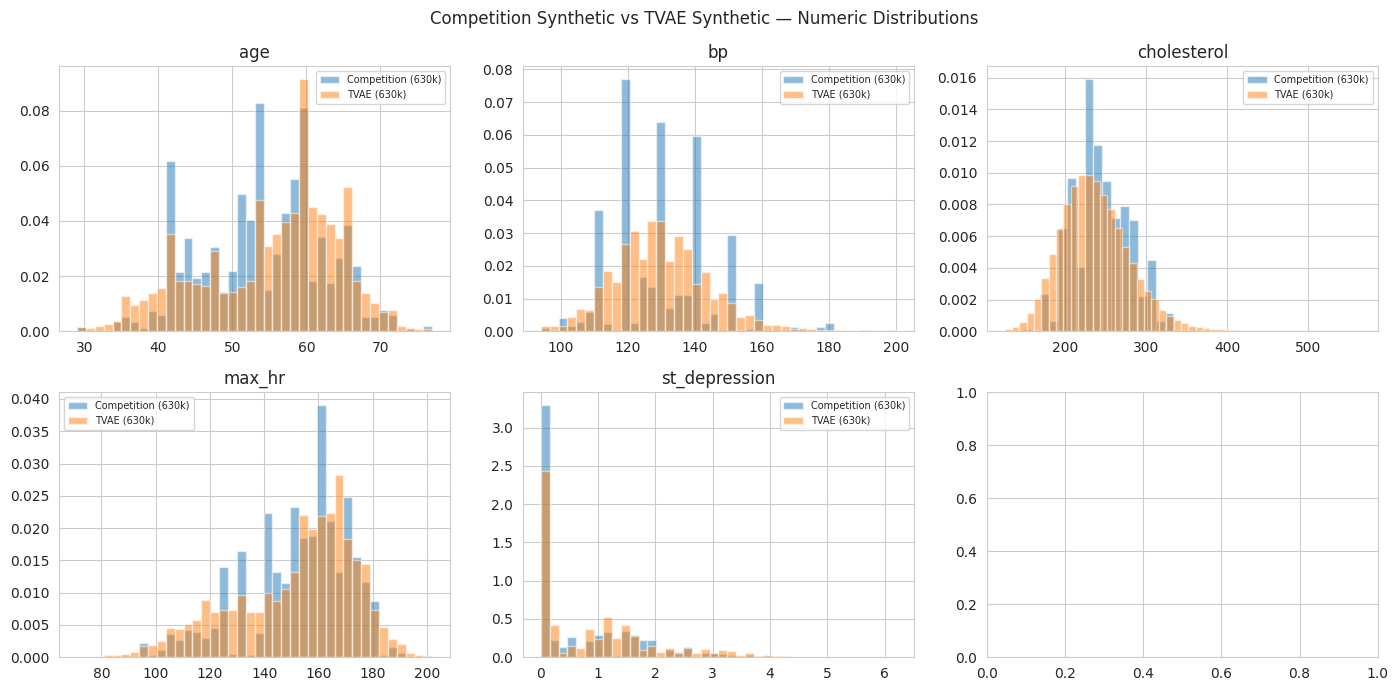

Positive rate — Competition: 0.448  TVAE: 0.478

Categorical value coverage (TVAE vs competition):
  ✓ sex: competition=[0, 1]  tvae=[0, 1]
  ✓ chest_pain_type: competition=[1, 2, 3, 4]  tvae=[1, 2, 3, 4]
  ✓ fbs_over_120: competition=[0, 1]  tvae=[0, 1]
  ✓ ekg_results: competition=[0, 1, 2]  tvae=[0, 1, 2]
  ✓ exercise_angina: competition=[0, 1]  tvae=[0, 1]
  ✓ slope_of_st: competition=[1, 2, 3]  tvae=[1, 2, 3]
  ✓ number_of_vessels_fluro: competition=[0, 1, 2, 3]  tvae=[0, 1, 2, 3]
  ✓ thallium: competition=[3, 6, 7]  tvae=[3, 6, 7]


In [2]:
NUM_FEATURES = [f for f in FEATURES if f not in CAT_FEATURES]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, NUM_FEATURES):
    comp_train[col].hist(bins=40, ax=ax, alpha=0.5, label='Competition (630k)', density=True)
    synth[col].hist(     bins=40, ax=ax, alpha=0.5, label='TVAE (630k)', density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.suptitle('Competition Synthetic vs TVAE Synthetic — Numeric Distributions')
plt.tight_layout()
plt.show()

print('Positive rate — Competition: {:.3f}  TVAE: {:.3f}'.format(
    y_comp.mean(), y_synth.mean()))

print('\nCategorical value coverage (TVAE vs competition):')
for col in CAT_FEATURES:
    comp_vals = set(comp_train[col].unique())
    tvae_vals = set(synth[col].unique())
    match = '✓' if comp_vals == tvae_vals else '✗'
    print(f'  {match} {col}: competition={sorted(comp_vals)}  tvae={sorted(tvae_vals)}')

## 5-Fold CV on TVAE Synthetic Data

Note: this CV measures fit *within* our synthetic distribution, not competition generalization.
The LB score is the real comparison point.

In [3]:
COMP_BASELINE_CV = 0.95533
COMP_BASELINE_LB = 0.95356

cv5        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof        = np.zeros(len(y_synth))
test_folds = np.zeros((5, len(X_test)))

for fold, (tr_idx, val_idx) in enumerate(cv5.split(X_synth, y_synth)):
    m = cb.CatBoostClassifier(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        task_type='GPU',
        cat_features=CAT_FEATURES,
        random_state=42,
        verbose=0,
        eval_metric='AUC',
        early_stopping_rounds=50,
    )
    m.fit(
        X_synth.iloc[tr_idx], y_synth[tr_idx],
        eval_set=(X_synth.iloc[val_idx], y_synth[val_idx]),
        verbose=False
    )
    oof[val_idx]     = m.predict_proba(X_synth.iloc[val_idx])[:, 1]
    test_folds[fold] = m.predict_proba(X_test)[:, 1]
    fold_auc = roc_auc_score(y_synth[val_idx], oof[val_idx])
    print(f'Fold {fold+1}: AUC={fold_auc:.5f}  best_iter={m.get_best_iteration()}')

cv_auc     = roc_auc_score(y_synth, oof)
test_preds = test_folds.mean(axis=0)

print(f'\nCV AUC (within TVAE synthetic): {cv_auc:.5f}')
print(f'Competition CV AUC:              {COMP_BASELINE_CV:.5f}')
print('(Not directly comparable — different train distributions)')

Default metric period is 5 because AUC is/are not implemented for GPU


Fold 1: AUC=0.98531  best_iter=542


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 2: AUC=0.98485  best_iter=393


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 3: AUC=0.98487  best_iter=524


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 4: AUC=0.98477  best_iter=483


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 5: AUC=0.98498  best_iter=411

CV AUC (within TVAE synthetic): 0.98495
Competition CV AUC:              0.95533
(Not directly comparable — different train distributions)


## Cross-Evaluation: TVAE Model on Competition Train Data

Train on full TVAE synthetic data, score on competition train.csv.
This measures how well our synthetic distribution matches the competition's.

In [4]:
# Train on full TVAE synthetic
m_full = cb.CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    task_type='GPU',
    cat_features=CAT_FEATURES,
    random_state=42,
    verbose=0,
)
m_full.fit(X_synth, y_synth)

# Score on competition train (held-out, never seen during training)
comp_preds = m_full.predict_proba(X_comp)[:, 1]
cross_auc  = roc_auc_score(y_comp, comp_preds)

print(f'TVAE model → competition train AUC: {cross_auc:.5f}')
print()
print('Interpretation:')
print(f'  ~0.955+ : TVAE data nearly as good as competition data')
print(f'  ~0.93-0.95: TVAE captures the general pattern but misses nuance')
print(f'  <0.93   : significant distributional gap between generators')

TVAE model → competition train AUC: 0.93715

Interpretation:
  ~0.955+ : TVAE data nearly as good as competition data
  ~0.93-0.95: TVAE captures the general pattern but misses nuance
  <0.93   : significant distributional gap between generators


## Submit

In [5]:
label = 'cat_tvae_synthetic_630k'
fname = f'submissions/{label}.csv'

sub = ss.copy()
sub['Heart Disease'] = test_preds
sub.to_csv(fname, index=False)
print(f'Saved: {fname}')

desc = f'{label} | cv_auc={cv_auc:.4f}'
r = subprocess.run(
    ['kaggle', 'competitions', 'submit', '-c', 'playground-series-s6e2',
     '-f', fname, '-m', desc],
    capture_output=True, text=True
)
status = 'submitted' if 'successfully' in r.stdout.lower() else r.stdout.strip()[:120]
print(f'{label}: {status}')
print(f'desc: {desc}')
print(f'\nWatch for LB score — compare to competition baseline LB = {COMP_BASELINE_LB}')

Saved: submissions/cat_tvae_synthetic_630k.csv
cat_tvae_synthetic_630k: submitted
desc: cat_tvae_synthetic_630k | cv_auc=0.9850

Watch for LB score — compare to competition baseline LB = 0.95356
